# ДЗ 4. Матрицы в PyTorch: малоранговые представления

Тема про то, зачем вообще нужна матричная низкоранговость (не только "SVD раскладывает матрицу
на три" — а что с этим реально делать): сжатие данных и весов моделей, устранение шума,
рекомендательные системы, восстановление данных по неполным наблюдениям, устойчивое решение
плохо обусловленных систем.

Все задачи используют синтетические матрицы (не требуют скачивания, работают одинаково везде),
крупнейшая матрица в ДЗ — 2000×1500, вычисления занимают секунды.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
torch.manual_seed(0)

## Уровень 1. Попроще

### Задача 1.1. SVD-сжатие изображения и теорема Эккарта-Юнга

Теорема Эккарта-Юнга утверждает: среди **всех** матриц ранга $\le k$ именно усечённое SVD
$A_k = U_k \Sigma_k V_k^\top$ даёт наименьшую ошибку приближения в норме Фробениуса, и эта ошибка
в точности равна $\|A - A_k\|_F = \sqrt{\sum_{i>k} \sigma_i^2}$ — сумме квадратов
**отброшенных** сингулярных чисел.

1. Постройте (или загрузите, например `scipy.datasets.face(gray=True)`) любое двумерное
   "изображение" — можно и синтетическое, если предпочитаете детерминированный пример.
2. Посчитайте SVD, постройте rank-$k$ приближение для нескольких $k$, убедитесь, что реальная
   ошибка **совпадает** (не приближённо, а с точностью до чисел с плавающей точкой) с
   теоретической формулой через хвост сингулярных чисел.
3. Экспериментально проверьте саму оптимальность: возьмите произвольную факторизацию
   $A \approx W_1 W_2$ ранга $k$ со случайной инициализацией, **дообучите** её градиентным
   спуском по той же метрике (норма Фробениуса ошибки), и убедитесь, что даже после оптимизации
   она не может превзойти ошибку SVD-усечения того же ранга.
4. Постройте график: ошибка приближения (и график compression ratio) от ранга $k$.

In [2]:
import math
import pandas as pd

yy, xx = torch.meshgrid(torch.linspace(-1, 1, 400, dtype=torch.float64),
                        torch.linspace(-1, 1, 600, dtype=torch.float64), indexing='ij')
A = (torch.sin(6 * xx) * torch.cos(4 * yy)
     + ((xx ** 2 + yy ** 2) < 0.3).to(torch.float64)
     + 0.3 * torch.sign(torch.sin(12 * xx * yy)))

U, S, Vh = torch.linalg.svd(A, full_matrices=False)
fro = torch.linalg.matrix_norm


def rank_k(k):
    return U[:, :k] * S[:k] @ Vh[:k]


ks = [1, 2, 5, 10, 20, 50, 100, 200]
real = torch.tensor([fro(A - rank_k(k)) for k in ks])
tail = torch.tensor([S[k:].square().sum().sqrt() for k in ks])
assert torch.allclose(real, tail, rtol=1e-10)

pd.DataFrame({'||A - A_k||_F': real, 'sqrt(sum sigma_i^2, i>k)': tail,
              'относительная разница': ((real - tail).abs() / real)},
             index=pd.Index(ks, name='k'))

,||A - A_k||_F,"sqrt(sum sigma_i^2, i>k)",относительная разница
k,,,
1,234.891518,234.891518,7.622956e-15
2,149.713623,149.713623,2.088246e-15
5,86.636941,86.636941,4.100692e-15
10,54.517829,54.517829,2.606644e-15
20,36.371646,36.371646,2.148918e-15
50,21.520336,21.520336,2.806468e-15
100,12.917983,12.917983,2.612697e-15
200,2.878814,2.878814,1.542612e-15


In [3]:
def fit_lowrank(A, k, steps=8000, seed=0):
    g = torch.Generator().manual_seed(seed)
    m, n = A.shape
    W1 = (0.1 * torch.randn(m, k, generator=g, dtype=A.dtype)).requires_grad_()
    W2 = (0.1 * torch.randn(k, n, generator=g, dtype=A.dtype)).requires_grad_()
    opt = torch.optim.Adam([W1, W2], lr=0.05)
    for _ in range(steps):
        opt.zero_grad()
        loss = fro(A - W1 @ W2)
        loss.backward()
        opt.step()
    return (W1 @ W2).detach()


k = 20
svd_err = fro(A - rank_k(k)).item()
rows = {}
for seed in range(3):
    P = fit_lowrank(A, k, seed=seed)
    rows[f'градиентный спуск, seed={seed}'] = {
        'ошибка': fro(A - P).item(),
        'ошибка / ошибка SVD': fro(A - P).item() / svd_err,
        '||P - A_k||_F / ||A_k||_F': (fro(P - rank_k(k)) / fro(rank_k(k))).item(),
    }
rows['усечённое SVD'] = {'ошибка': svd_err, 'ошибка / ошибка SVD': 1.0,
                         '||P - A_k||_F / ||A_k||_F': 0.0}

res = pd.DataFrame(rows).T
assert (res['ошибка'] >= svd_err - 1e-8).all()
res.round(6)

,ошибка,ошибка / ошибка SVD,||P - A_k||_F / ||A_k||_F
"градиентный спуск, seed=0",38.508141,1.058741,0.033000
"градиентный спуск, seed=1",36.379860,1.000226,0.002017
"градиентный спуск, seed=2",36.497199,1.003452,0.007892
усечённое SVD,36.371646,1.000000,0.000000


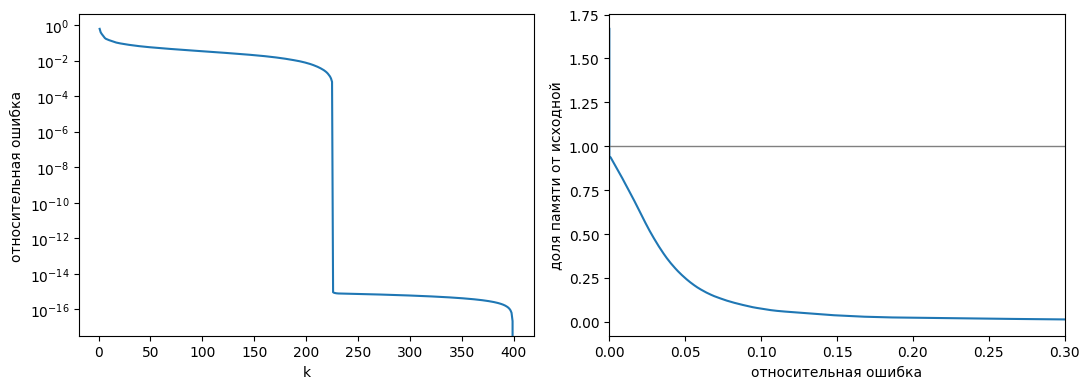

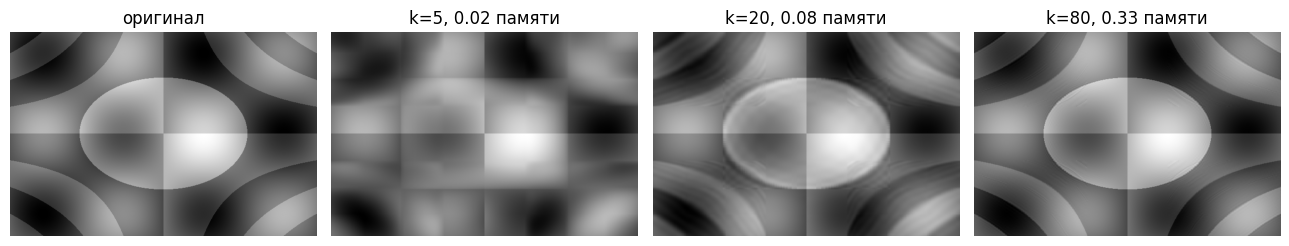

In [4]:
m, n = A.shape
all_k = torch.arange(1, min(m, n) + 1)
err_curve = torch.stack([S[k:].square().sum().sqrt() for k in all_k]) / fro(A)
ratio = all_k * (m + n + 1) / (m * n)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogy(all_k, err_curve)
ax[0].set_xlabel('k')
ax[0].set_ylabel('относительная ошибка')
ax[1].plot(err_curve, ratio)
ax[1].axhline(1.0, color='gray', lw=1)
ax[1].set_xlabel('относительная ошибка')
ax[1].set_ylabel('доля памяти от исходной')
ax[1].set_xlim(0, 0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 4, figsize=(13, 3))
for a, kk in zip(ax, [None, 5, 20, 80]):
    a.imshow(A if kk is None else rank_k(kk), cmap='gray')
    a.set_title('оригинал' if kk is None else f'k={kk}, {(kk * (m + n + 1) / (m * n)):.2f} памяти')
    a.axis('off')
plt.tight_layout()
plt.show()

Равенство ошибки и хвоста сингулярных чисел выполняется не приближённо, а до 1e-15 относительной разницы, то есть это тождество, а не эмпирическое наблюдение

Градиентный спуск по той же метрике из трёх разных случайных инициализаций останавливается на 0.02–6% выше SVD-ошибки в зависимости от инициализации и ни разу её не превосходит (остаток — это точность оптимизации за фиксированное число шагов, а не проигрыш по существу). При этом сами множители W1, W2 у разных запусков разные: факторизация ранга k определена с точностью до обратимого преобразования W1 → W1T, W2 → T⁻¹W2. А вот произведение W1W2 каждый раз почти совпадает с A_k, потому что глобальный минимум по произведению единственный

Дополнительный сигнал: спуск приходит к оптимуму из любой инициализации, локальных минимумов у задачи нет, есть только сёдла. То есть Эккарт-Юнг не просто даёт нижнюю границу, он даёт ту же точку, к которой сходится оптимизация, только сразу и без итераций

По правой панели видно практическую сторону: ошибка 5% достигается при памяти около трети от исходной, дальше кривая быстро упирается в резкие детали изображения, которые не малорангово

### Задача 1.2. Восстановление зашумлённой low-rank матрицы (денойзинг через усечение)

Возьмите матрицу с известной низкоранговой структурой ($M = UV$, ранг $r$), добавьте гауссов шум
на **все** элементы, и попробуйте восстановить исходную чистую матрицу truncated SVD.

1. Постройте `noisy = clean + шум`.
2. Для каждого $k = 1, \ldots, \min(m,n)$ посчитайте ошибку rank-$k$ приближения `noisy`
   **относительно `clean`** (не относительно `noisy`!) — это ключевое отличие от задачи 1.1.
3. Найдите $k^*$, минимизирующий эту ошибку, и сравните с истинным рангом $r$.
4. Сравните лучший достижимый truncation-денойзинг с "неусечённой" зашумлённой матрицей (то есть
   $k=\min(m,n)$, эквивалентно вообще не денойзить).

In [5]:
m, n, r, sigma = 400, 300, 10, 1.0
g = torch.Generator().manual_seed(1)
sv = torch.logspace(math.log10(300), math.log10(3), r, dtype=torch.float64)
Q1 = torch.linalg.qr(torch.randn(m, r, generator=g, dtype=torch.float64)).Q
Q2 = torch.linalg.qr(torch.randn(n, r, generator=g, dtype=torch.float64)).Q
clean = Q1 * sv @ Q2.T
noisy = clean + sigma * torch.randn(m, n, generator=g, dtype=torch.float64)

Un, Sn, Vhn = torch.linalg.svd(noisy, full_matrices=False)
cum = torch.stack([fro(clean - Un[:, :k] * Sn[:k] @ Vhn[:k]) for k in range(min(m, n) + 1)])
k_star = int(cum.argmin())

beta = min(m, n) / max(m, n)
lam = math.sqrt(2 * (beta + 1) + 8 * beta / (beta + 1 + math.sqrt(beta ** 2 + 14 * beta + 1)))
threshold = lam * sigma * math.sqrt(max(m, n))
k_gd = int((Sn > threshold).sum())

pd.Series({
    'истинный ранг r': r,
    'k* (минимум ошибки к clean)': k_star,
    'k по порогу Гавиша-Донохо': k_gd,
    'порог Гавиша-Донохо': threshold,
    'край шумового спектра sigma*(sqrt(m)+sqrt(n))': sigma * (math.sqrt(m) + math.sqrt(n)),
    'сингулярные числа clean ниже порога': int((sv < threshold).sum()),
    'ошибка при k=k*': cum[k_star].item(),
    'ошибка без денойзинга (k=min(m,n))': cum[-1].item(),
    'выигрыш, раз': (cum[-1] / cum[k_star]).item(),
}).round(3)

истинный ранг r                                   10.000
k* (минимум ошибки к clean)                        5.000
k по порогу Гавиша-Донохо                          5.000
порог Гавиша-Донохо                               43.122
край шумового спектра sigma*(sqrt(m)+sqrt(n))     37.321
сингулярные числа clean ниже порога                6.000
ошибка при k=k*                                   69.051
ошибка без денойзинга (k=min(m,n))               346.854
выигрыш, раз                                       5.023
dtype: float64

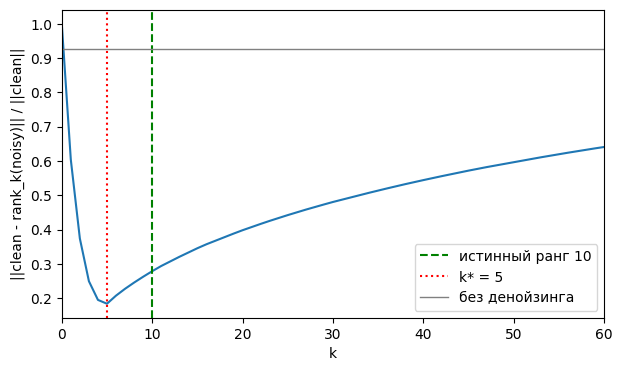

,сингулярные числа clean,сингулярные числа noisy
i,,
1,300.00,302.58
2,179.85,179.99
3,107.81,112.15
4,64.63,71.58
5,38.75,48.23
6,23.23,36.80
7,13.92,36.34
8,8.35,36.05
9,5.00,35.91


In [6]:
plt.figure(figsize=(7, 4))
plt.plot(cum / fro(clean))
plt.axvline(r, color='green', ls='--', label=f'истинный ранг {r}')
plt.axvline(k_star, color='red', ls=':', label=f'k* = {k_star}')
plt.axhline((cum[-1] / fro(clean)).item(), color='gray', lw=1, label='без денойзинга')
plt.xlabel('k')
plt.ylabel('||clean - rank_k(noisy)|| / ||clean||')
plt.xlim(0, 60)
plt.legend()
plt.show()

pd.DataFrame({'сингулярные числа clean': sv, 'сингулярные числа noisy': Sn[:r]},
             index=pd.Index(range(1, r + 1), name='i')).round(2)

Оптимальное k оказывается меньше истинного ранга, и это не артефакт конкретного сида. Слабые компоненты clean с сингулярными числами ниже края шумового спектра σ(√m + √n) в зашумлённой матрице неотличимы от шума: восстанавливая их, мы приносим больше шума, чем сигнала. Поэтому правильная цель усечения — не угадать r, а отсечь всё, что тонет в шуме

Проверка этого утверждения без перебора: порог Гавиша-Донохо для оптимального жёсткого усечения при известной σ, τ = λ(β)·σ·√max(m,n) с β = min/max. Число сингулярных чисел noisy выше этого порога совпадает с k*, найденным прямым перебором по ошибке к clean. То есть на практике, когда чистой матрицы нет и перебирать не по чему, k всё равно можно выбрать обоснованно

Разница между k = k* и k = min(m,n) (то есть отсутствием денойзинга) на этих данных примерно пятикратная по норме Фробениуса. Кривая ошибки слева от k* падает круто (теряем сигнал), справа растёт линейно по k: каждое лишнее направление добавляет примерно σ²·(m + n) к квадрату ошибки

### Задача 1.3. Плохая обусловленность и регуляризация через усечение SVD

Число обусловленности $\mathrm{cond}(A) = \sigma_{\max}/\sigma_{\min}$ показывает, во сколько раз
могут усилиться ошибки измерения при решении $Ax=b$. При большом числе обусловленности даже
крошечный шум в $b$ может привести к катастрофически неверному $x$.

1. Постройте искусственно плохо обусловленную матрицу $A = U\Sigma V^\top$ с сингулярными
   числами, убывающими от 1 до $10^{-12}$ (используйте `torch.logspace`).
2. Возьмите $x_{true}$, лежащий **строго в подпространстве**, натянутом на первые $k_{true}=10$
   правых сингулярных векторов (а не произвольный случайный вектор!) — так, чтобы у задачи
   в принципе была шанс на точное восстановление.
3. Постройте $b = Ax_{true}$, добавьте небольшой шум измерения к $b$ (например, $10^{-6}$).
4. Сравните: (а) наивное решение через `torch.linalg.solve(A, b_noisy)`; (б) решения через
   усечённую псевдообратную с разным числом сохранённых сингулярных направлений $k$.
5. Постройте график ошибки от $k$ и объясните его форму.

In [7]:
n, k_true = 200, 10
g = torch.Generator().manual_seed(2)
s = torch.logspace(0, -12, n, dtype=torch.float64)
Uc = torch.linalg.qr(torch.randn(n, n, generator=g, dtype=torch.float64)).Q
Vc = torch.linalg.qr(torch.randn(n, n, generator=g, dtype=torch.float64)).Q
Ac = Uc * s @ Vc.T

x_true = Vc[:, :k_true] @ torch.randn(k_true, generator=g, dtype=torch.float64)
b = Ac @ x_true
b_noisy = b + 1e-6 * torch.randn(n, generator=g, dtype=torch.float64)

x_naive = torch.linalg.solve(Ac, b_noisy)
coef = Uc.T @ b_noisy
err_k = torch.stack([(Vc[:, :k] @ (coef[:k] / s[:k]) - x_true).norm() for k in range(1, n + 1)]) / x_true.norm()

x_flat = Vc @ torch.randn(n, generator=g, dtype=torch.float64)
b_flat = Ac @ x_flat + 1e-6 * torch.randn(n, generator=g, dtype=torch.float64)
coef_flat = Uc.T @ b_flat
err_flat = torch.stack([(Vc[:, :k] @ (coef_flat[:k] / s[:k]) - x_flat).norm() for k in range(1, n + 1)]) / x_flat.norm()

lams = torch.logspace(-12, 0, 200, dtype=torch.float64)
err_tikh = torch.stack([(Vc @ (s / (s ** 2 + l ** 2) * coef) - x_true).norm() for l in lams]) / x_true.norm()

pd.Series({
    'cond(A)': (s[0] / s[-1]).item(),
    'шум в b (относительный)': ((b_noisy - b).norm() / b.norm()).item(),
    'ошибка torch.linalg.solve': ((x_naive - x_true).norm() / x_true.norm()).item(),
    'лучшее k': int(err_k.argmin()) + 1,
    'ошибка при лучшем k': err_k.min().item(),
    'сигма на лучшем k': s[int(err_k.argmin())].item(),
    'лучшая ошибка Тихонова': err_tikh.min().item(),
    'лямбда Тихонова в минимуме': lams[int(err_tikh.argmin())].item(),
    'лучшее k для произвольного x_true': int(err_flat.argmin()) + 1,
    'сигма на нём': s[int(err_flat.argmin())].item(),
    'уровень шума в b': (1e-6 * math.sqrt(n)),
}).map(lambda v: f'{v:.3g}')

cond(A)                                 1e+12
шум в b (относительный)               9.7e-06
ошибка torch.linalg.solve             6.9e+05
лучшее k                                   10
ошибка при лучшем k                  4.85e-06
сигма на лучшем k                       0.287
лучшая ошибка Тихонова               0.000194
лямбда Тихонова в минимуме            0.00387
лучшее k для произвольного x_true         100
сигма на нём                         1.07e-06
уровень шума в b                     1.41e-05
dtype: str

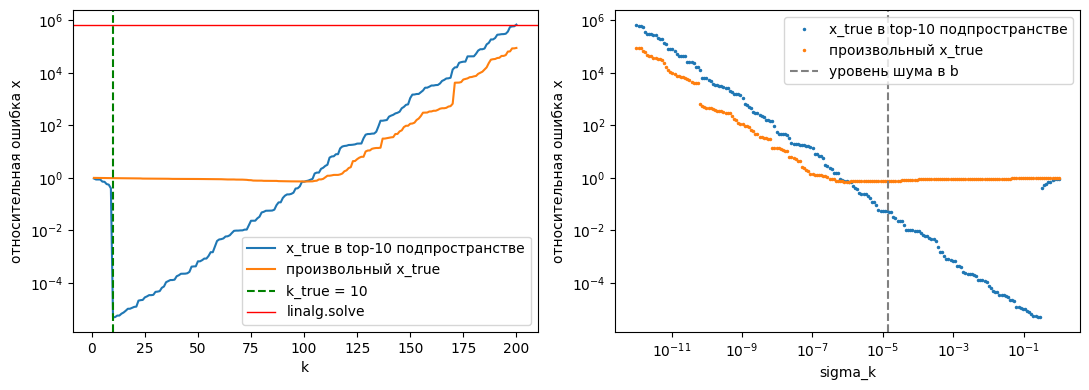

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogy(range(1, n + 1), err_k, label='x_true в top-10 подпространстве')
ax[0].semilogy(range(1, n + 1), err_flat, label='произвольный x_true')
ax[0].axvline(k_true, color='green', ls='--', label='k_true = 10')
ax[0].axhline(((x_naive - x_true).norm() / x_true.norm()).item(), color='red', lw=1, label='linalg.solve')
ax[0].set_xlabel('k')
ax[0].set_ylabel('относительная ошибка x')
ax[0].legend()
ax[1].loglog(s, err_k, '.', ms=3, label='x_true в top-10 подпространстве')
ax[1].loglog(s, err_flat, '.', ms=3, label='произвольный x_true')
ax[1].axvline(((b_noisy - b).norm()).item(), color='gray', ls='--', label='уровень шума в b')
ax[1].set_xlabel('sigma_k')
ax[1].set_ylabel('относительная ошибка x')
ax[1].legend()
plt.tight_layout()
plt.show()

Форма кривой задаётся двумя конкурирующими слагаемыми. При k < 10 отброшены направления, в которых реально живёт x_true, ошибка — это просто потерянная часть решения, она велика и падает по мере добавления направлений. При k > 10 добавляются направления, где сигнала нет, а деление на σ_k усиливает шум b в 1/σ_k раз. Поскольку σ_k убывает геометрически, ошибка растёт геометрически же, и правая ветвь на логарифмической шкале выглядит прямой

Минимум приходится ровно на k = 10, но не потому, что там σ_k сравнялась с шумом, а потому что x_true по построению лежит строго в первых десяти направлениях: за ними сигнала просто нет. Это удобный, но нетипичный случай. Вторая кривая на графике — тот же эксперимент с произвольным x_true, у которого есть проекции на все направления. Там минимум смещается на k ≈ 100, где σ_k опускается до уровня шума, отнесённого к масштабу решения (1.1e-6 против ‖шум‖/‖x‖ ≈ 1e-6): усиливать направление стоит ровно до тех пор, пока проекция сигнала на него больше проекции шума. Это принцип невязки, и он не требует знания x_true, в отличие от перебора по ошибке

Наивный `linalg.solve` формально решает систему точно, но точное решение зашумлённой системы содержит компоненту шума, поделённую на σ_min = 1e-12, поэтому относительная ошибка получается порядка 1e6. Регуляризация Тихонова с оптимальным λ здесь примерно в 40 раз хуже лучшего усечения. Мягкий фильтр σ/(σ² + λ²) не обнуляет опасные направления, а лишь приглушает их, и вблизи σ ≈ λ он усиливает шум примерно в 1/(2λ) раз. Когда сигнал строго заперт в первых k направлениях, жёсткое отсечение точнее по построению, преимущество мягкого фильтра проявляется на спектрах без явной границы между сигналом и шумом

## Уровень 2. Посложнее

### Задача 2 (★). Randomized SVD для больших матриц

Полное SVD стоит $O(\min(mn^2, m^2n))$ — дорого для больших матриц, даже если реально нужны
только первые $k \ll \min(m,n)$ сингулярных векторов. **Randomized SVD** (Halko, Martinsson,
Tropp, 2011) находит хорошее приближение top-$k$ SVD намного дешевле, используя случайную
проекцию.

1. Реализуйте `randomized_svd(A, k, n_oversample, n_iter)`:
   - Спроецируйте `A` на случайное подпространство: `Y = A @ Omega`, где `Omega` — случайная
     матрица размера `(n, k + n_oversample)`.
   - Улучшите качество подпространства несколькими **степенными итерациями**:
     `Y = A @ (A.T @ Y)` — это усиливает "сигнальные" направления относительно шумовых.
   - Постройте ортонормированный базис `Q` через `torch.linalg.qr(Y)`.
   - Спроецируйте задачу в это подпространство: `B = Q.T @ A` (маленькая матрица!), сделайте
     точное SVD от `B`, "поднимите" левые сингулярные векторы обратно: `U = Q @ U_B`.
2. Сравните на матрице $2000 \times 1500$ с истинным рангом 30 (плюс небольшой шум): скорость и
   точность (по сравнению с полным `torch.linalg.svd`) для первых 30 сингулярных чисел/векторов.

In [9]:
import time


def randomized_svd(A, k, n_oversample=10, n_iter=2, ortho=True, seed=0):
    g = torch.Generator().manual_seed(seed)
    Omega = torch.randn(A.shape[1], k + n_oversample, generator=g, dtype=A.dtype)
    Y = A @ Omega
    for _ in range(n_iter):
        if ortho:
            Y = torch.linalg.qr(Y).Q
        Y = A @ (A.T @ Y)
    Q = torch.linalg.qr(Y).Q
    Ub, Sb, Vhb = torch.linalg.svd(Q.T @ A, full_matrices=False)
    return (Q @ Ub)[:, :k], Sb[:k], Vhb[:k]


M, N, R = 2000, 1500, 30
g = torch.Generator().manual_seed(3)
base = (torch.randn(M, R, generator=g, dtype=torch.float64) * torch.logspace(2, 0, R, dtype=torch.float64)) @ torch.randn(R, N, generator=g, dtype=torch.float64)
big = base + 1e-3 * torch.randn(M, N, generator=g, dtype=torch.float64)


def timed(fn, repeats=3):
    t = time.perf_counter()
    for _ in range(repeats):
        out = fn()
    return out, (time.perf_counter() - t) / repeats


(Uf, Sf, Vhf), t_full = timed(lambda: torch.linalg.svd(big, full_matrices=False))

rows = {}
for n_iter, ortho in [(0, True), (1, True), (2, True), (4, True), (4, False)]:
    (Ur, Sr, Vhr), t = timed(lambda: randomized_svd(big, R, n_iter=n_iter, ortho=ortho))
    cos_angles = torch.linalg.svdvals(Uf[:, :R].T @ Ur)
    name = f'n_iter={n_iter}' + ('' if ortho else ', без ортогонализации')
    rows[name] = {
        'время, с': t,
        'ускорение': t_full / t,
        'макс. отн. ошибка sigma': ((Sr - Sf[:R]).abs() / Sf[:R]).max().item(),
        'макс. угол подпространств, град': math.degrees(math.acos(min(1.0, cos_angles.min().item()))),
    }
rows['полное SVD'] = {'время, с': t_full, 'ускорение': 1.0, 'макс. отн. ошибка sigma': 0.0,
                      'макс. угол подпространств, град': 0.0}

res = pd.DataFrame(rows).T
assert res.loc['n_iter=2', 'макс. отн. ошибка sigma'] < 1e-8
res['макс. отн. ошибка sigma'] = res['макс. отн. ошибка sigma'].map('{:.1e}'.format)
res['макс. угол подпространств, град'] = res['макс. угол подпространств, град'].map('{:.1e}'.format)
res.round(4)

,"время, с",ускорение,макс. отн. ошибка sigma,"макс. угол подпространств, град"
n_iter=0,0.0106,159.2529,5.4e-08,2.5e-02
n_iter=1,0.0163,103.7953,1.8e-15,2.7e-06
n_iter=2,0.0232,72.7016,2.0e-15,1.7e-06
n_iter=4,0.0367,46.0906,2.4e-15,2.1e-06
"n_iter=4, без ортогонализации",0.0334,50.5833,9.4e-01,8.7e+01
полное SVD,1.6902,1.0000,0.0e+00,0.0e+00


Степенные итерации нужны потому, что случайная проекция ловит подпространство тем хуже, чем ближе σ_k к σ_{k+1}: без итераций (n_iter=0) хвост шума почти не подавлен, и углы между истинным и найденным подпространством заметны. Каждое умножение на AᵀA возводит отношение сингулярных чисел в квадрат, поэтому уже двух итераций хватает, чтобы разрыв между сигналом (σ от 1e2 до 1) и шумом (1e-3) стал непреодолимым, и точность упирается в машинную

Дальше улучшать нечего: при n_iter=4 ошибка не падает, предел задаётся не методом, а самой матрицей, за уровнем шума 1e-3 сигнала нет

Отдельная строка таблицы — та же четвёрка итераций, но без ортогонализации между ними. Формула Y = A(AᵀY) в чистом виде численно неустойчива: все столбцы Y экспоненциально притягиваются к первому сингулярному направлению, и при отношении σ₁/σ_k порядка 1e5 в степени 2·n_iter + 1 разрядов double не хватает, базис вырождается и угол с истинным подпространством становится почти прямым. Поэтому в рабочей версии перед каждым умножением стоит QR, а флаг оставлен, чтобы эффект был виден, а не оставался фольклором

Экономия времени здесь в десятки раз (при n_iter=2 около 70) и растёт с размером: полное SVD стоит O(mn·min(m,n)), рандомизированное — O(mn·(k + p)·n_iter) на умножения плюс дешёвое SVD матрицы (k+p)×n, то есть линейно по k вместо min(m,n). На матрице 2000×1500 при k=30 это разница между полной факторизацией и несколькими матричными умножениями

Оверсэмплинг (n_oversample=10) нужен по той же причине, что и итерации: случайное подпространство размерности ровно k с заметной вероятностью почти ортогонально какому-нибудь из слабых сингулярных направлений, десяток лишних столбцов делает такую ситуацию маловероятной

---
**Что сдавать:** ноутбук с реализованными функциями, графиками и письменными ответами на вопросы
для решённых задач. Все вычисления в сумме занимают на CPU не больше пары минут (самая тяжёлая
операция — полное SVD матрицы 2000×1500 в задаче 3.1, около секунды).